# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:

import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

print("✅ Semua library berhasil diimpor!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Semua library berhasil diimpor!
   pandas  : 2.2.2
   numpy   : 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df_raw = df.copy()

print("✅ Dataset berhasil dimuat!")
print(f"   Nama file     : {file_name}")
print(f"   Jumlah baris  : {df.shape[0]:,}")
print(f"   Jumlah kolom  : {df.shape[1]}")
print()

print("5 Baris Pertama:")
display(df.head())

print()

print("5 Baris Terakhir:")
display(df.tail())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
✅ Dataset berhasil dimuat!
   Nama file     : WA_Fn-UseC_-Telco-Customer-Churn (1).csv
   Jumlah baris  : 7,043
   Jumlah kolom  : 21

5 Baris Pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes



5 Baris Terakhir:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.8000,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.2000,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.6000,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.4000,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.6500,6844.5,No


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
print("=" * 60)
print("         INFORMASI UMUM DATASET")
print("=" * 60)
print(f"\nShape  : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print()
df.info()

         INFORMASI UMUM DATASET

Shape  : 7,043 baris x 21 kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 

In [4]:
print("📊 Statistik Deskriptif — Fitur Numerik:")
display(df.describe())

print("\n📊 Statistik Deskriptif — Fitur Kategorikal:")
display(df.describe(include='object'))

📊 Statistik Deskriptif — Fitur Numerik:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.0000,7043.0000,7043.0000
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500



📊 Statistik Deskriptif — Fitur Kategorikal:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [5]:
print("🔍 Pengecekan Missing Values")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah'] > 0]

if missing_df.empty:
    print("✅ Tidak ada NaN langsung terdeteksi.\n")
else:
    display(missing_df)

spaces = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f"⚠️  Hidden missing values pada 'TotalCharges': {spaces} baris")
print(f"   → Nilainya berupa string kosong (spasi), bukan NaN")
print(f"   → Akan dikonversi menjadi NaN saat preprocessing")

🔍 Pengecekan Missing Values
✅ Tidak ada NaN langsung terdeteksi.

⚠️  Hidden missing values pada 'TotalCharges': 11 baris
   → Nilainya berupa string kosong (spasi), bukan NaN
   → Akan dikonversi menjadi NaN saat preprocessing


In [6]:
total_dups = df.duplicated().sum()
print(f"🔍 Jumlah baris duplikat: {total_dups}")
if total_dups == 0:
    print("✅ Tidak ada data duplikat!")
else:
    print(f"⚠️  Ditemukan {total_dups} baris duplikat → akan dihapus saat preprocessing")
    display(df[df.duplicated()])

🔍 Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


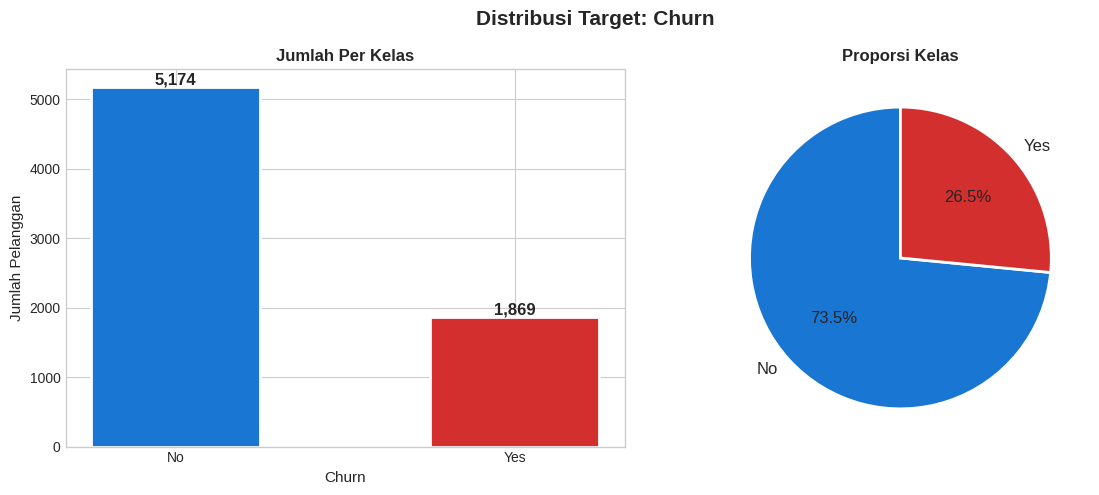


📊 Distribusi Churn:
      No: 5,174 (73.5%)
     Yes: 1,869 (26.5%)

⚠️  Dataset IMBALANCED — perlu diperhatikan saat modeling


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target: Churn', fontsize=15, fontweight='bold')

churn_counts = df['Churn'].value_counts()
colors = ['#1976D2', '#D32F2F']

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[0].set_title('Jumlah Per Kelas', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Churn', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Distribusi Churn:")
for label, count in churn_counts.items():
    print(f"   {label:>5}: {count:,} ({count/len(df)*100:.1f}%)")
print("\n⚠️  Dataset IMBALANCED — perlu diperhatikan saat modeling")

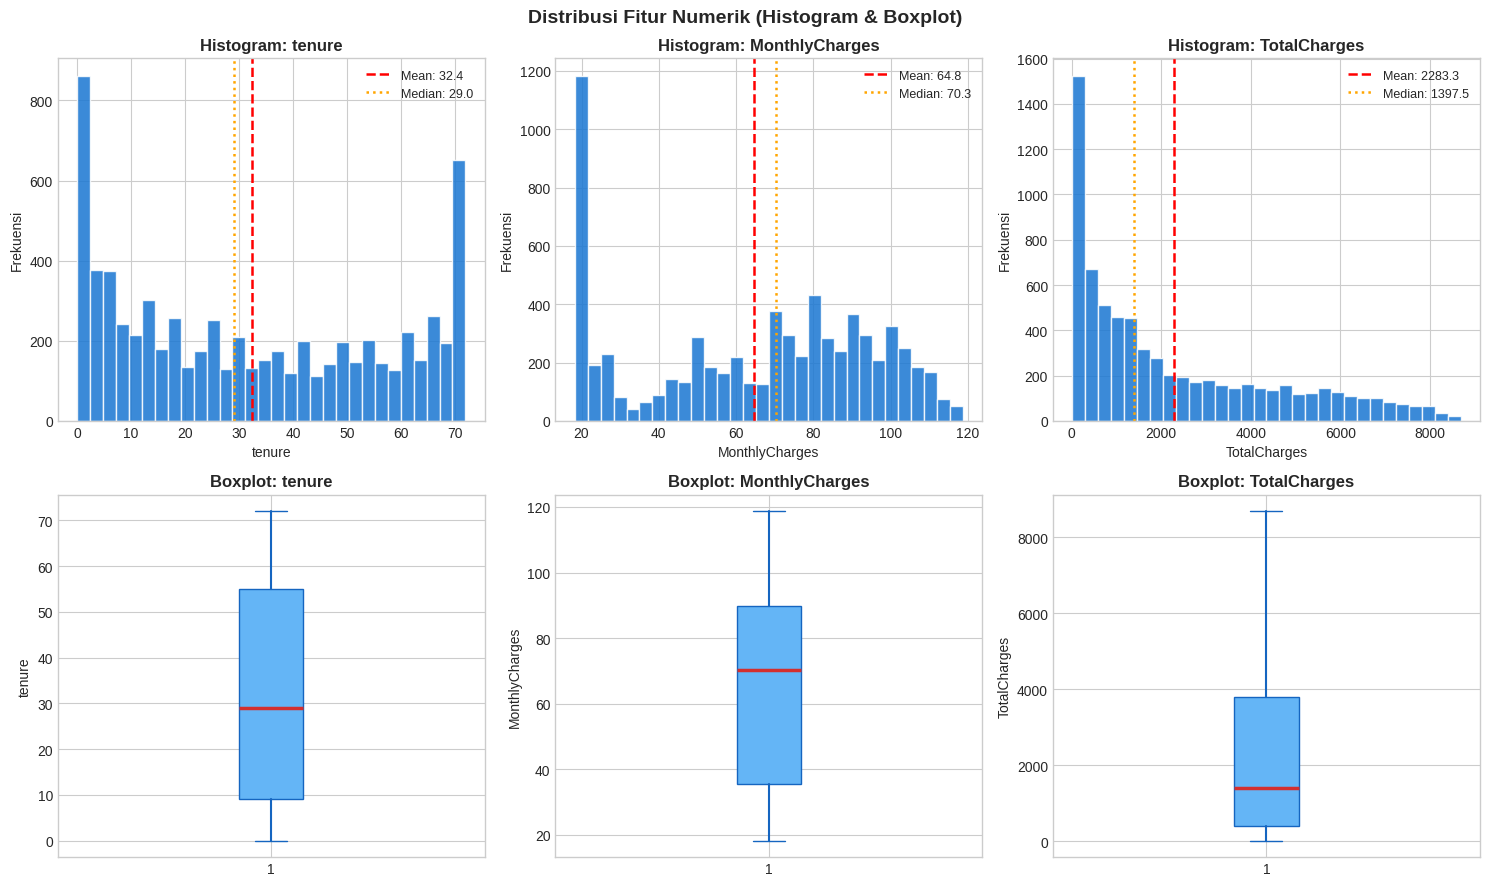


📊 Statistik Fitur Numerik:


,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3700,64.7600,2283.3000
std,24.5600,30.0900,2266.7700
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4800
75%,55.0000,89.8500,3794.7400
max,72.0000,118.7500,8684.8000


In [8]:
df_vis = df.copy()
df_vis['TotalCharges'] = pd.to_numeric(df_vis['TotalCharges'], errors='coerce')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribusi Fitur Numerik (Histogram & Boxplot)', fontsize=14, fontweight='bold')

for i, col in enumerate(numerical_cols):
    data = df_vis[col].dropna()

    # Histogram
    axes[0, i].hist(data, bins=30, color='#1976D2', edgecolor='white', alpha=0.85)
    axes[0, i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.8,
                        label=f'Mean: {data.mean():.1f}')
    axes[0, i].axvline(data.median(), color='orange', linestyle=':', linewidth=1.8,
                        label=f'Median: {data.median():.1f}')
    axes[0, i].set_title(f'Histogram: {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')
    axes[0, i].legend(fontsize=9)

    # Boxplot
    axes[1, i].boxplot(data, patch_artist=True,
                        boxprops=dict(facecolor='#64B5F6', color='#1565C0'),
                        medianprops=dict(color='#D32F2F', linewidth=2.5),
                        whiskerprops=dict(color='#1565C0', linewidth=1.5),
                        capprops=dict(color='#1565C0'),
                        flierprops=dict(marker='o', color='#F44336', alpha=0.4, markersize=4))
    axes[1, i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.savefig('eda_02_numerical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Statistik Fitur Numerik:")
display(df_vis[numerical_cols].describe().round(2))

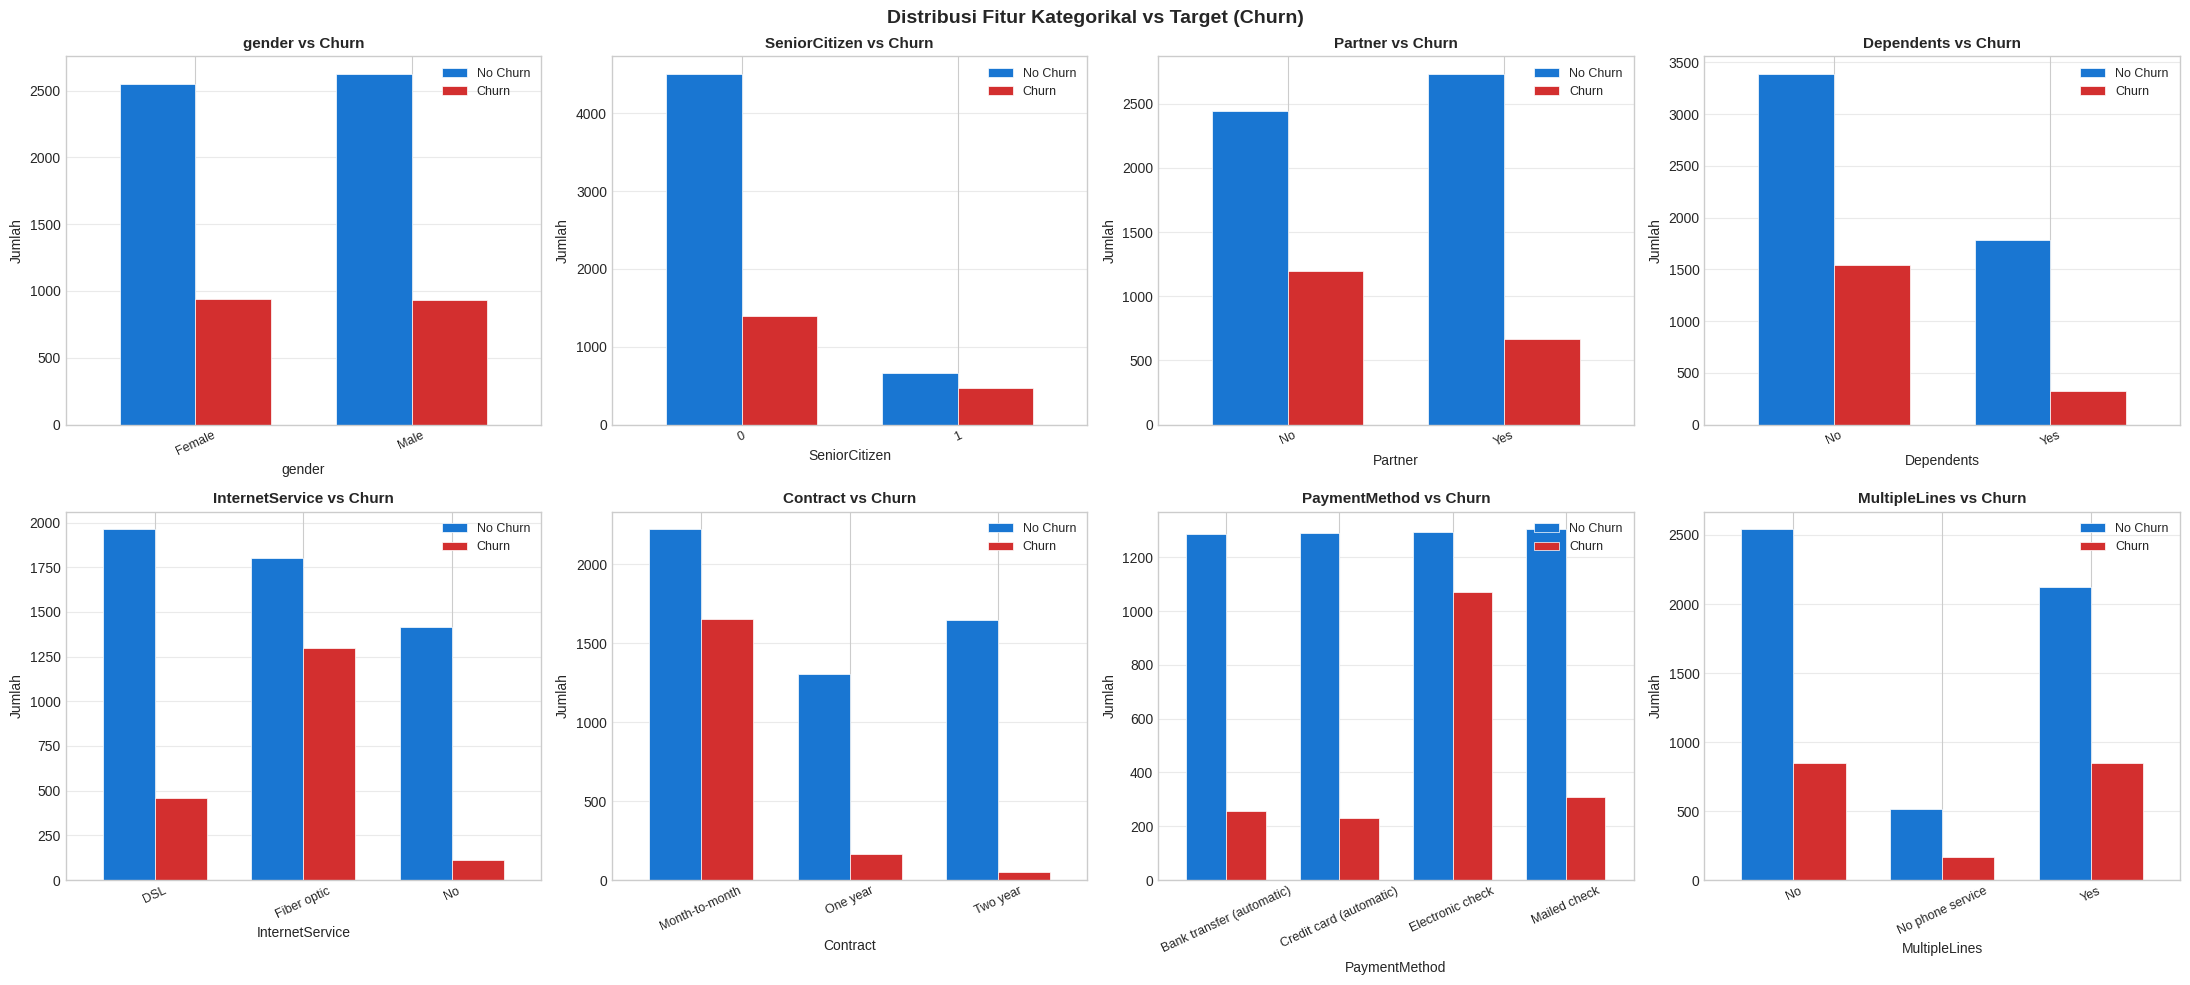

Insight dari visualisasi:
   - Contract month-to-month memiliki churn rate tertinggi
   - Pelanggan tanpa partner/dependent lebih rentan churn
   - Fiber optic memiliki churn lebih tinggi dari DSL


In [9]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()
colors_bar = ['#1976D2', '#D32F2F']

for i, col in enumerate(cat_cols):
    crosstab = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    crosstab.plot(kind='bar', ax=axes[i], color=colors_bar,
                  edgecolor='white', linewidth=0.5, width=0.7)
    axes[i].set_title(f'{col} vs Churn', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Jumlah', fontsize=10)
    axes[i].tick_params(axis='x', rotation=25, labelsize=9)
    axes[i].legend(['No Churn', 'Churn'], fontsize=9)
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Distribusi Fitur Kategorikal vs Target (Churn)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_categorical_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()

print("Insight dari visualisasi:")
print("   - Contract month-to-month memiliki churn rate tertinggi")
print("   - Pelanggan tanpa partner/dependent lebih rentan churn")
print("   - Fiber optic memiliki churn lebih tinggi dari DSL")

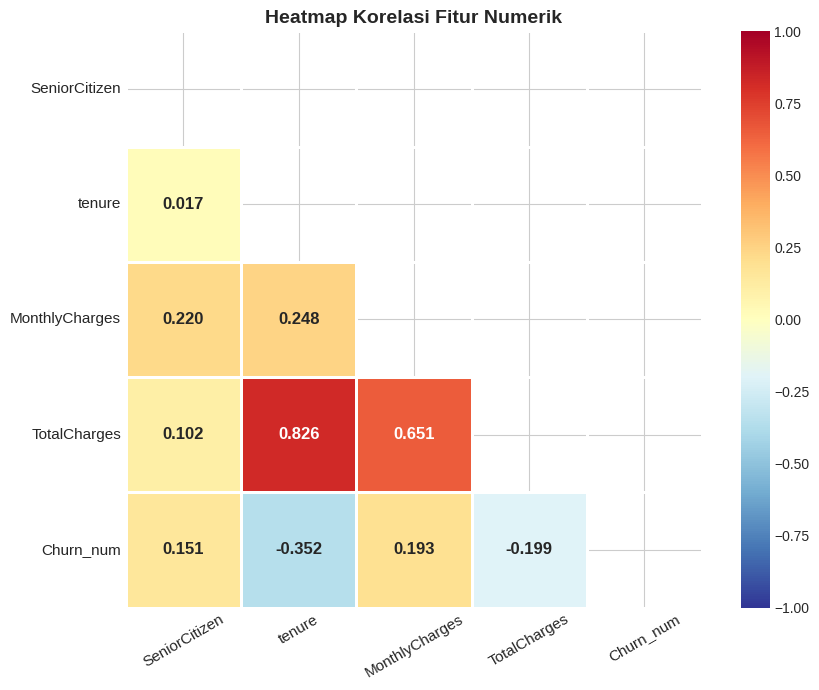


📊 Korelasi dengan Target (Churn):
   tenure              : 0.3522  ████████
   TotalCharges        : 0.1995  ████
   MonthlyCharges      : 0.1934  ████
   SeniorCitizen       : 0.1509  ███


In [10]:
df_corr = df.copy()
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

num_cols_corr = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
corr_matrix = df_corr[num_cols_corr].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            mask=mask, vmin=-1, vmax=1, square=True,
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, rotation=30)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Korelasi dengan Target (Churn):")
corr_target = corr_matrix['Churn_num'].drop('Churn_num').abs().sort_values(ascending=False)
for feat, val in corr_target.items():
    bar_vis = '█' * int(val * 25)
    print(f"   {feat:<20}: {val:.4f}  {bar_vis}")

In [11]:
print("=" * 60)
print("           RINGKASAN HASIL EDA")
print("=" * 60)

df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

print(f"\n📌 Dataset      : Telco Customer Churn")
print(f"📌 Shape        : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"📌 Duplikat     : {df.duplicated().sum()}")
print(f"📌 Missing (NaN): {df_temp.isnull().sum().sum()} (TotalCharges hidden: {spaces})")

print(f"\n📊 Distribusi Target:")
for label, count in df['Churn'].value_counts().items():
    print(f"   - {label}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\n🔎 Rencana Preprocessing:")
print(f"   1. Konversi 'TotalCharges' Object → Float (+ tangani {spaces} hidden NaN)")
print(f"   2. Isi missing values TotalCharges dengan Median")
print(f"   3. Hapus kolom 'customerID' (tidak informatif untuk model)")
print(f"   4. Label Encoding semua fitur kategorikal")
print(f"   5. StandardScaler fitur numerik: tenure, MonthlyCharges, TotalCharges")
print(f"   6. Train/Test Split — 80:20 (stratified berdasarkan target)")
print(f"   7. Simpan ke folder 'telco_preprocessing/'")
print(f"\n✅ Siap masuk ke tahap Data Preprocessing!")

           RINGKASAN HASIL EDA

📌 Dataset      : Telco Customer Churn
📌 Shape        : 7,043 baris x 21 kolom
📌 Duplikat     : 0
📌 Missing (NaN): 11 (TotalCharges hidden: 11)

📊 Distribusi Target:
   - No: 5,174 (73.5%)
   - Yes: 1,869 (26.5%)

🔎 Rencana Preprocessing:
   1. Konversi 'TotalCharges' Object → Float (+ tangani 11 hidden NaN)
   2. Isi missing values TotalCharges dengan Median
   3. Hapus kolom 'customerID' (tidak informatif untuk model)
   4. Label Encoding semua fitur kategorikal
   5. StandardScaler fitur numerik: tenure, MonthlyCharges, TotalCharges
   6. Train/Test Split — 80:20 (stratified berdasarkan target)
   7. Simpan ke folder 'telco_preprocessing/'

✅ Siap masuk ke tahap Data Preprocessing!


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
print("🔄 [5.1] Konversi Tipe Data 'TotalCharges'...")
print(f"   Dtype sebelum : {df['TotalCharges'].dtype}")
print(f"   Contoh nilai  : {df['TotalCharges'].head(5).tolist()}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"\n   Dtype sesudah  : {df['TotalCharges'].dtype}")
print(f"   Missing values : {df['TotalCharges'].isnull().sum()} (dari konversi string kosong)")
print("   ✅ Berhasil!")

🔄 [5.1] Konversi Tipe Data 'TotalCharges'...
   Dtype sebelum : object
   Contoh nilai  : ['29.85', '1889.5', '108.15', '1840.75', '151.65']

   Dtype sesudah  : float64
   Missing values : 11 (dari konversi string kosong)
   ✅ Berhasil!


In [13]:
print("🔧 [5.2] Penanganan Missing Values...")

median_val = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_val, inplace=True)

print(f"   Kolom         : TotalCharges")
print(f"   Metode        : Isi dengan Median")
print(f"   Nilai Median  : {median_val:.2f}")
print(f"   Missing tersisa: {df['TotalCharges'].isnull().sum()}")
print(f"   Total missing seluruh dataset: {df.isnull().sum().sum()}")
print("   ✅ Berhasil!")

🔧 [5.2] Penanganan Missing Values...
   Kolom         : TotalCharges
   Metode        : Isi dengan Median
   Nilai Median  : 1397.47
   Missing tersisa: 0
   Total missing seluruh dataset: 0
   ✅ Berhasil!


In [14]:
print("🗑️ [5.3] Menghapus Kolom 'customerID'...")
print(f"   Shape sebelum : {df.shape}")

df.drop('customerID', axis=1, inplace=True)

print(f"   Shape sesudah : {df.shape}")
print(f"   Kolom tersisa : {list(df.columns)}")
print("   ✅ Berhasil!")

🗑️ [5.3] Menghapus Kolom 'customerID'...
   Shape sebelum : (7043, 21)
   Shape sesudah : (7043, 20)
   Kolom tersisa : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
   ✅ Berhasil!


In [15]:
print("🔤 [5.4] Label Encoding Fitur Kategorikal...")
print("=" * 60)

categorical_cols = [c for c in df.select_dtypes(include='object').columns if c != 'Churn']
print(f"Jumlah kolom diproses : {len(categorical_cols)}")
print(f"Kolom                 : {categorical_cols}\n")

le = LabelEncoder()
encoding_map = {}

for col in categorical_cols:
    unique_vals = sorted(df[col].unique())
    df[col] = le.fit_transform(df[col])
    encoding_map[col] = {v: int(le.transform([v])[0]) for v in unique_vals}
    print(f"   ✅ {col:<30}: {unique_vals}")

# Encode target: No=0, Yes=1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f"   ✅ {'Churn (Target)':<30}: ['No', 'Yes'] → [0, 1]")

print(f"\n📊 Preview 5 baris setelah encoding:")
display(df.head())

🔤 [5.4] Label Encoding Fitur Kategorikal...
Jumlah kolom diproses : 15
Kolom                 : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

   ✅ gender                        : ['Female', 'Male']
   ✅ Partner                       : ['No', 'Yes']
   ✅ Dependents                    : ['No', 'Yes']
   ✅ PhoneService                  : ['No', 'Yes']
   ✅ MultipleLines                 : ['No', 'No phone service', 'Yes']
   ✅ InternetService               : ['DSL', 'Fiber optic', 'No']
   ✅ OnlineSecurity                : ['No', 'No internet service', 'Yes']
   ✅ OnlineBackup                  : ['No', 'No internet service', 'Yes']
   ✅ DeviceProtection              : ['No', 'No internet service', 'Yes']
   ✅ TechSupport                   : ['No', 'No internet service', 'Yes']
   ✅ StreamingTV      

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.8500,29.8500,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.9500,1889.5000,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.8500,108.1500,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.3000,1840.7500,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.7000,151.6500,1


In [16]:
print("📏 [5.5] Standarisasi Fitur Numerik (StandardScaler)...")
print("=" * 60)

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Sebelum standarisasi:")
display(df[numerical_features].describe().round(4))

scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nSesudah standarisasi (mean ≈ 0, std ≈ 1):")
display(df[numerical_features].describe().round(4))
print("   ✅ Berhasil!")

📏 [5.5] Standarisasi Fitur Numerik (StandardScaler)...
Sebelum standarisasi:


,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7043.0000
mean,32.3711,64.7617,2281.9169
std,24.5595,30.0900,2265.2704
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,402.2250
50%,29.0000,70.3500,1397.4750
75%,55.0000,89.8500,3786.6000
max,72.0000,118.7500,8684.8000



Sesudah standarisasi (mean ≈ 0, std ≈ 1):


,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7043.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-1.3182,-1.5459,-0.9991
25%,-0.9517,-0.9725,-0.8298
50%,-0.1373,0.1857,-0.3905
75%,0.9215,0.8338,0.6643
max,1.6137,1.7944,2.8267


   ✅ Berhasil!


In [17]:
print("✂️ [5.6] Pembagian Dataset — 80% Train | 20% Test...")
print("=" * 60)

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"   Features (X) : {X.shape}")
print(f"   Target   (y) : {y.shape}")
print(f"   Kolom fitur  : {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split selesai (stratified):")
print(f"   Training set  : {X_train.shape[0]:,} baris | Churn={y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Testing set   : {X_test.shape[0]:,} baris  | Churn={y_test.sum()} ({y_test.mean()*100:.1f}%)")

✂️ [5.6] Pembagian Dataset — 80% Train | 20% Test...
   Features (X) : (7043, 19)
   Target   (y) : (7043,)
   Kolom fitur  : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

✅ Split selesai (stratified):
   Training set  : 5,634 baris | Churn=1495 (26.5%)
   Testing set   : 1,409 baris  | Churn=374 (26.5%)


In [18]:
print("💾 [5.7] Menyimpan Dataset Hasil Preprocessing...")
print("=" * 60)

output_dir = 'telco_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan kembali X dan y
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

# Simpan tiga file
train_df.to_csv(f'{output_dir}/train.csv',              index=False)
test_df.to_csv(f'{output_dir}/test.csv',                index=False)
df.to_csv(f'{output_dir}/full_preprocessed.csv',        index=False)

print(f"\n✅ File tersimpan di folder '{output_dir}/':")
print(f"   📄 train.csv              → {train_df.shape[0]:,} baris x {train_df.shape[1]} kolom")
print(f"   📄 test.csv               → {test_df.shape[0]:,} baris x {test_df.shape[1]} kolom")
print(f"   📄 full_preprocessed.csv  → {df.shape[0]:,} baris x {df.shape[1]} kolom")

print(f"\n{'='*60}")
print("🎉 PREPROCESSING SELESAI! Dataset siap digunakan untuk modeling.")
print('='*60)

display(train_df.head())

💾 [5.7] Menyimpan Dataset Hasil Preprocessing...

✅ File tersimpan di folder 'telco_preprocessing/':
   📄 train.csv              → 5,634 baris x 20 kolom
   📄 test.csv               → 1,409 baris x 20 kolom
   📄 full_preprocessed.csv  → 7,043 baris x 20 kolom

🎉 PREPROCESSING SELESAI! Dataset siap digunakan untuk modeling.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,0.1070,0,1,0,0,0,2,0,2,2,0,0,2,-0.5172,-0.2562,0
1,1,0,1,1,-0.7074,1,0,1,2,0,0,0,0,0,0,0,3,0.3436,-0.4990,0
2,1,0,1,1,-0.7888,0,1,0,2,2,0,2,0,0,2,0,3,-0.8047,-0.7468,0
3,0,0,1,0,-0.2594,1,0,0,0,2,2,0,2,2,2,1,1,0.2904,-0.1661,0
4,1,0,1,1,-1.2774,1,0,0,0,0,0,0,0,0,0,0,2,-0.6718,-0.9878,0
